In [1]:
# Demo file for working with univariate data
# live entstanden in der Vorlesung AIN Stochastik, 09.04.2026
#
# copyright: Barbara Staehle, HTWG Konstanz
# bstaehle@htwg-konstanz.de

# import library we use for plotting and calculating
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics as stat

In [2]:
# read data from excelfile
# for excel-file, see Moodle!
umfrage = pd.read_excel('../../data/zehn_Fragen_ss26_clean.xlsx')
# Daten ausgeben
#print(umfrage)

In [3]:
# nur die quantitativen Merkmale (Zahlen) der Umfrage
numvals = umfrage.drop(columns=umfrage.columns[:4])
numvals = numvals.drop(columns=numvals.columns[3])
numvals = numvals.drop(columns=numvals.columns[6])

#print(numvals)

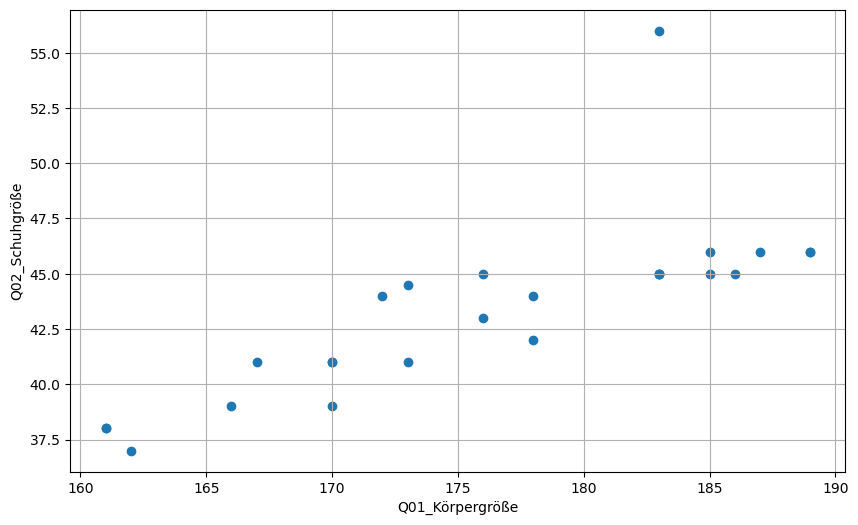

In [4]:
# Scatterplot Körpergröße vs. Schuhgröße
plt.figure(figsize=(10, 6))
plt.scatter(numvals['Q01_Körpergröße'], numvals['Q02_Schuhgröße'])
plt.grid(True)
plt.xlabel('Q01_Körpergröße')
plt.ylabel('Q02_Schuhgröße')
plt.show()

In [5]:
# Korrelationskoeffizient mit pandas
correlation = numvals[['Q01_Körpergröße', 'Q02_Schuhgröße']].corr()
print(correlation)

                 Q01_Körpergröße  Q02_Schuhgröße
Q01_Körpergröße         1.000000        0.774626
Q02_Schuhgröße          0.774626        1.000000


In [6]:
print('Korrelation', correlation.iloc[0,1])

Korrelation 0.7746264089385602


In [7]:
# Korrelationskoeffizient mit numpy
np.corrcoef(numvals[['Q01_Körpergröße', 'Q02_Schuhgröße']],rowvar=False)

array([[1.        , 0.77462641],
       [0.77462641, 1.        ]])

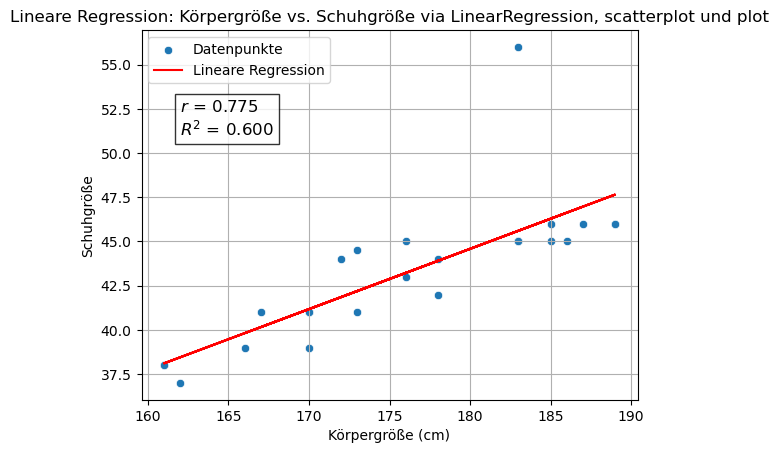

In [8]:
# Für den Schuh- und Körpergröße eine Regressionsgerade berechnen und plotten Coauthor: LeChat
import seaborn as sns
# Methode 1: Einfache lineare Regression haendisch erstellen
from sklearn.linear_model import LinearRegression

# Lineare Regression
x = numvals[['Q01_Körpergröße']]
y = numvals['Q02_Schuhgröße']

# Korrelationskoeffizient und Bestimmtheitsmaß ausrechnen 
r = numvals[['Q01_Körpergröße', 'Q02_Schuhgröße']].corr()
r = r.iloc[0, 1]
R2 = r**2

model_linear = LinearRegression()
model_linear.fit(x, y)
y_pred_linear = model_linear.predict(x)

sns.scatterplot(x='Q01_Körpergröße', y='Q02_Schuhgröße', data=numvals, label='Datenpunkte')
plt.plot(numvals['Q01_Körpergröße'], y_pred_linear, color='red', label='Lineare Regression')
plt.title('Lineare Regression: Körpergröße vs. Schuhgröße via LinearRegression, scatterplot und plot')
plt.xlabel('Körpergröße (cm)')
plt.ylabel('Schuhgröße')
plt.text(162, 51, f'$r$ = {r:.3f}\n$R^2$ = {R2:.3f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid(True)
plt.show()


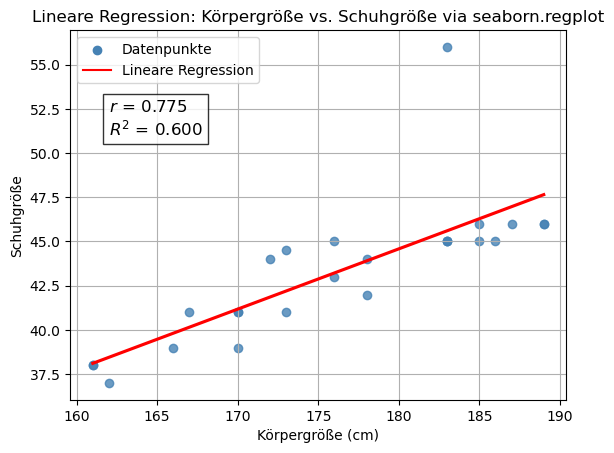

In [9]:
# Methode 2: Regression mit Seaborn (inkl. Konfidenzintervall)
ax = sns.regplot(
    x='Q01_Körpergröße',
    y='Q02_Schuhgröße',
    data=numvals,
    ci=None, # kein Konfidenzintervall
    scatter_kws={'color': 'steelblue'}, # Punkte in Blau
    line_kws={'color': 'red'}       # Linie in Rot
)
plt.grid(True)
plt.title('Lineare Regression: Körpergröße vs. Schuhgröße via seaborn.regplot')
plt.xlabel('Körpergröße (cm)')
plt.ylabel('Schuhgröße')

# Legende hinzufügen 
# haesslich, aber geht in seaborn nicht anders
ax.scatter([], [], color='steelblue', label='Datenpunkte')
ax.plot([], [], color='red', label='Lineare Regression')
ax.legend()

plt.text(162, 51, f'$r$ = {r:.3f}\n$R^2$ = {R2:.3f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.show()
